In [109]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

RANDOM_STATE = 42

In [110]:
DATA_PATH = "Sales Dataset.csv" 

df = pd.read_csv(DATA_PATH)

print("Kích thước dữ liệu ban đầu:", df.shape)
display(df)

Kích thước dữ liệu ban đầu: (1194, 12)


,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
...,...,...,...,...,...,...,...,...,...,...,...,...
1189,B-26370,8825,3594,15,Furniture,Tables,Debit Card,2024-07-31,Megan Mclean,New York,New York City,2024-07
1190,B-26298,2082,642,8,Electronics,Phones,EMI,2020-06-02,Caitlin Hunt,New York,Rochester,2020-06
1191,B-26298,2082,642,8,Electronics,Phones,EMI,2022-12-15,Jenna Holland,Texas,Austin,2022-12
1192,B-26298,2082,642,8,Electronics,Phones,EMI,2020-08-07,Stephanie Oconnell,New York,Buffalo,2020-08


In [111]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1194 non-null   object
 1   Amount        1194 non-null   int64 
 2   Profit        1194 non-null   int64 
 3   Quantity      1194 non-null   int64 
 4   Category      1194 non-null   object
 5   Sub-Category  1194 non-null   object
 6   PaymentMode   1194 non-null   object
 7   Order Date    1194 non-null   object
 8   CustomerName  1194 non-null   object
 9   State         1194 non-null   object
 10  City          1194 non-null   object
 11  Year-Month    1194 non-null   object
dtypes: int64(3), object(9)
memory usage: 112.1+ KB


,Amount,Profit,Quantity
count,1194.000000,1194.000000,1194.000000
mean,5178.089615,1348.992462,10.674204
std,2804.921955,1117.992573,5.777102
min,508.000000,50.000000,1.000000
25%,2799.000000,410.000000,6.000000
50%,5152.000000,1014.000000,11.000000
75%,7626.000000,2035.000000,16.000000
max,9992.000000,4930.000000,20.000000


In [112]:
# Xử lý mising
df.isnull().sum()
df = df.dropna()

# xử lý dữ liệu trùng
df.duplicated().sum()

df = df.drop_duplicates()



In [113]:
display(df)

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
...,...,...,...,...,...,...,...,...,...,...,...,...
1189,B-26370,8825,3594,15,Furniture,Tables,Debit Card,2024-07-31,Megan Mclean,New York,New York City,2024-07
1190,B-26298,2082,642,8,Electronics,Phones,EMI,2020-06-02,Caitlin Hunt,New York,Rochester,2020-06
1191,B-26298,2082,642,8,Electronics,Phones,EMI,2022-12-15,Jenna Holland,Texas,Austin,2022-12
1192,B-26298,2082,642,8,Electronics,Phones,EMI,2020-08-07,Stephanie Oconnell,New York,Buffalo,2020-08


In [114]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1194 non-null   object
 1   Amount        1194 non-null   int64 
 2   Profit        1194 non-null   int64 
 3   Quantity      1194 non-null   int64 
 4   Category      1194 non-null   object
 5   Sub-Category  1194 non-null   object
 6   PaymentMode   1194 non-null   object
 7   Order Date    1194 non-null   object
 8   CustomerName  1194 non-null   object
 9   State         1194 non-null   object
 10  City          1194 non-null   object
 11  Year-Month    1194 non-null   object
dtypes: int64(3), object(9)
memory usage: 112.1+ KB


,Amount,Profit,Quantity
count,1194.000000,1194.000000,1194.000000
mean,5178.089615,1348.992462,10.674204
std,2804.921955,1117.992573,5.777102
min,508.000000,50.000000,1.000000
25%,2799.000000,410.000000,6.000000
50%,5152.000000,1014.000000,11.000000
75%,7626.000000,2035.000000,16.000000
max,9992.000000,4930.000000,20.000000


In [115]:

# thêm cột profit margin
df["Profit_Margin"] = df["Profit"] / df["Amount"]

df = df.dropna(subset=["Profit_Margin"]).copy()

display(
    df[["Amount", "Profit", "Profit_Margin"]]
    .describe()
    .T
)




,count,mean,std,min,25%,50%,75%,max
Amount,1194.0,5178.089615,2804.921955,508.00000,2799.000000,5152.000000,7626.000000,9992.0
Profit,1194.0,1348.992462,1117.992573,50.00000,410.000000,1014.000000,2035.000000,4930.0
Profit_Margin,1194.0,0.260571,0.140518,0.00779,0.140665,0.255742,0.381925,0.5


In [116]:
threshold = 0.25
# Tạo cột rish label
df["Risk_Label"] = (
    df["Profit_Margin"] < threshold
).astype("int8")
#loại bỏ cột không cần thiết

df['Order Date'] = pd.to_datetime(df['Order Date'])

# Tách tháng (số)
df['Month'] = df['Order Date'].dt.month
drop_cols = ["Order ID", "CustomerName", "Year-Month","Order Date"]
df = df.drop(columns=drop_cols)

In [117]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Amount         1194 non-null   int64  
 1   Profit         1194 non-null   int64  
 2   Quantity       1194 non-null   int64  
 3   Category       1194 non-null   object 
 4   Sub-Category   1194 non-null   object 
 5   PaymentMode    1194 non-null   object 
 6   State          1194 non-null   object 
 7   City           1194 non-null   object 
 8   Profit_Margin  1194 non-null   float64
 9   Risk_Label     1194 non-null   int8   
 10  Month          1194 non-null   int32  
dtypes: float64(1), int32(1), int64(3), int8(1), object(5)
memory usage: 89.9+ KB


,Amount,Profit,Quantity,Profit_Margin,Risk_Label,Month
count,1194.000000,1194.000000,1194.000000,1194.000000,1194.000000,1194.00000
mean,5178.089615,1348.992462,10.674204,0.260571,0.482412,6.71273
std,2804.921955,1117.992573,5.777102,0.140518,0.499900,3.48755
min,508.000000,50.000000,1.000000,0.007790,0.000000,1.00000
25%,2799.000000,410.000000,6.000000,0.140665,0.000000,4.00000
50%,5152.000000,1014.000000,11.000000,0.255742,0.000000,7.00000
75%,7626.000000,2035.000000,16.000000,0.381925,1.000000,10.00000
max,9992.000000,4930.000000,20.000000,0.500000,1.000000,12.00000


In [118]:
counts = df['Risk_Label'].value_counts()
percent = df['Risk_Label'].value_counts(normalize=True) * 100

result = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percent
})

print(result)

            Count  Percentage (%)
Risk_Label                       
0             618       51.758794
1             576       48.241206


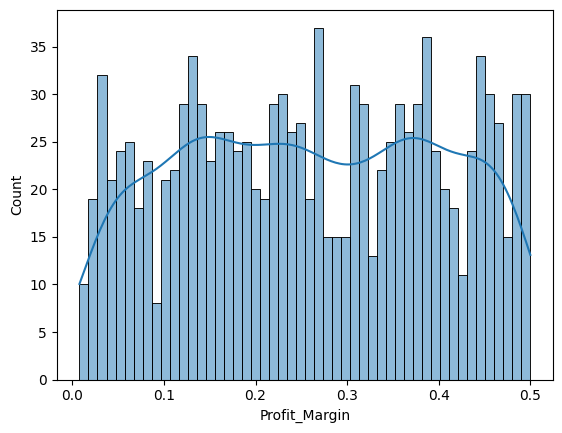

In [119]:

sns.histplot(df["Profit_Margin"], bins=50, kde=True)
plt.show()

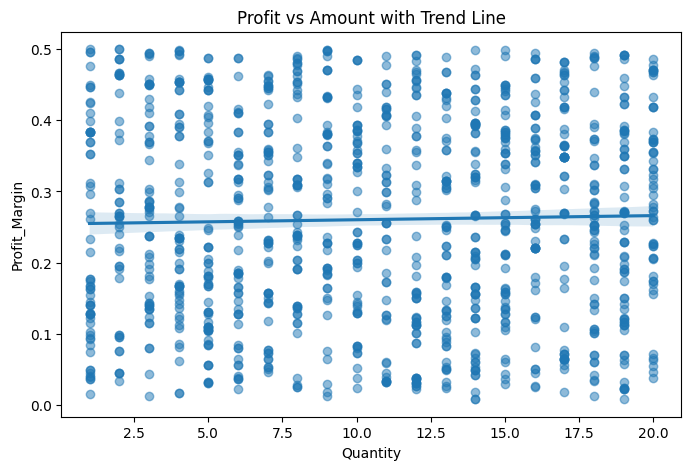

In [120]:
plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Quantity",
    y="Profit_Margin",
    scatter_kws={"alpha":0.5}
)

plt.title("Profit vs Amount with Trend Line")
plt.show()

In [121]:
display(df)

,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,State,City,Profit_Margin,Risk_Label,Month
0,9726,1275,5,Electronics,Electronic Games,UPI,Florida,Miami,0.131092,1,6
1,9726,1275,5,Electronics,Electronic Games,UPI,Illinois,Chicago,0.131092,1,12
2,9726,1275,5,Electronics,Electronic Games,UPI,New York,Buffalo,0.131092,1,7
3,4975,1330,14,Electronics,Printers,UPI,Florida,Miami,0.267337,0,6
4,4975,1330,14,Electronics,Printers,UPI,Illinois,Chicago,0.267337,0,12
...,...,...,...,...,...,...,...,...,...,...,...
1189,8825,3594,15,Furniture,Tables,Debit Card,New York,New York City,0.407252,0,7
1190,2082,642,8,Electronics,Phones,EMI,New York,Rochester,0.308357,0,6
1191,2082,642,8,Electronics,Phones,EMI,Texas,Austin,0.308357,0,12
1192,2082,642,8,Electronics,Phones,EMI,New York,Buffalo,0.308357,0,8


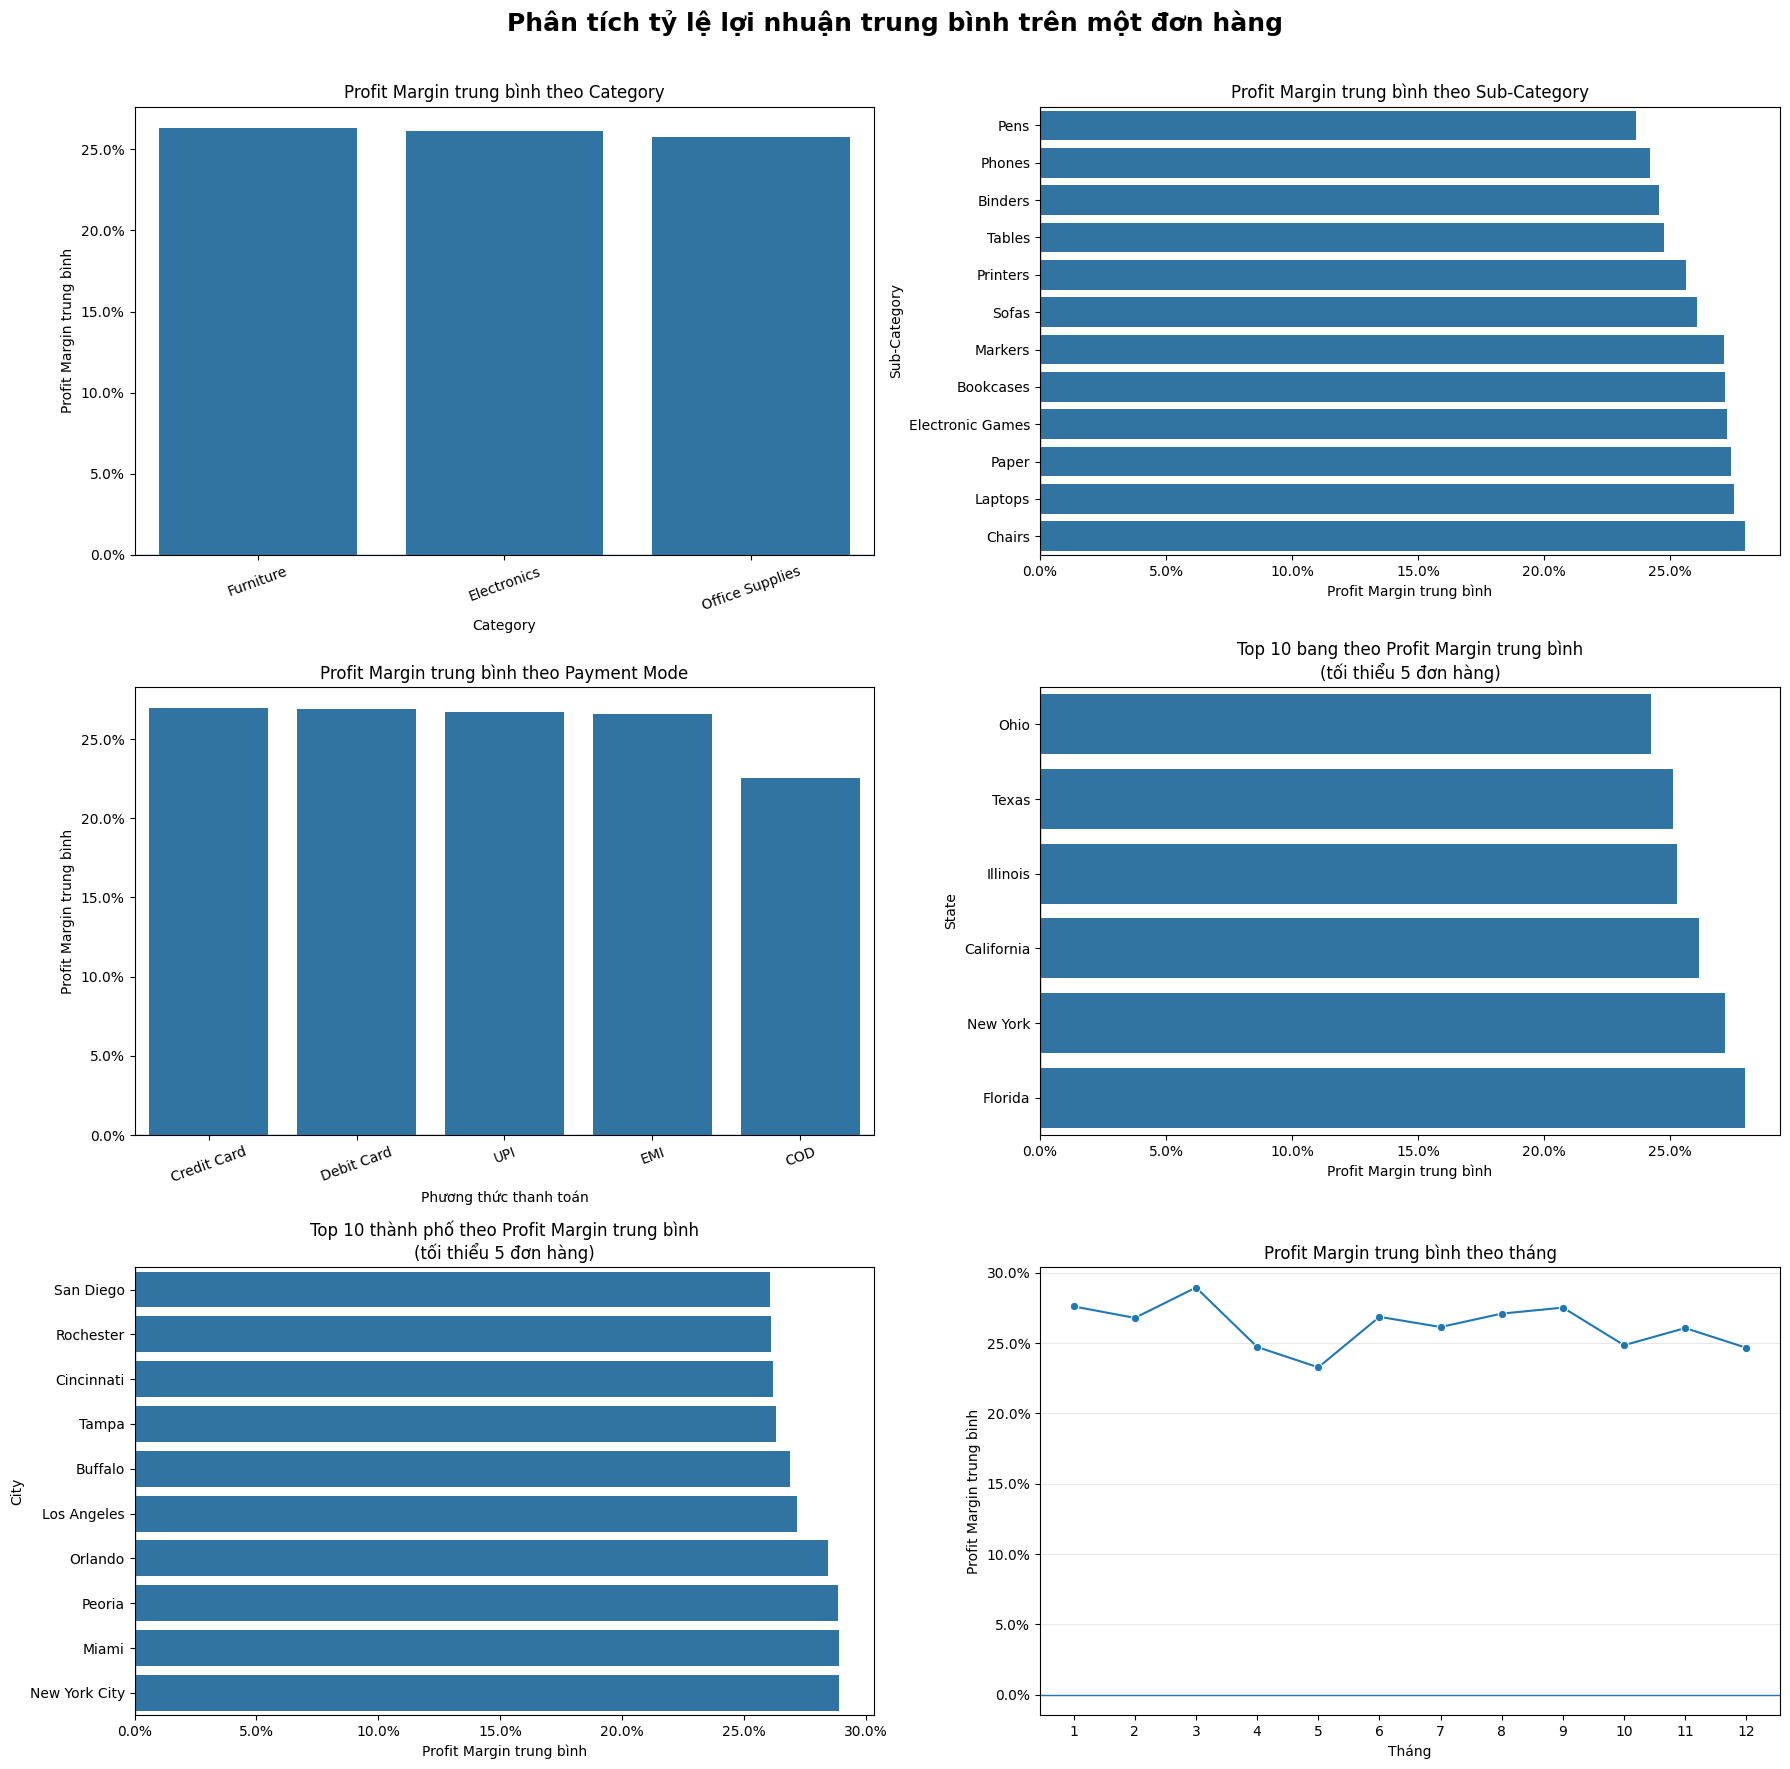

In [122]:


from matplotlib.ticker import PercentFormatter

category_margin = (
    df.groupby("Category", observed=True)["Profit_Margin"]
    .mean()
    .sort_values(ascending=False)
)

subcategory_margin = (
    df.groupby("Sub-Category", observed=True)["Profit_Margin"]
    .mean()
    .sort_values(ascending=True)
)

payment_margin = (
    df.groupby("PaymentMode", observed=True)["Profit_Margin"]
    .mean()
    .sort_values(ascending=False)
)

# Tính thêm số đơn để tránh nhóm có quá ít dữ liệu
state_stats = (
    df.groupby("State", observed=True)
    .agg(
        Avg_Margin=("Profit_Margin", "mean"),
        Order_Count=("Profit_Margin", "size")
    )
)

# Chỉ giữ bang có ít nhất 5 đơn, sau đó lấy top 10
state_margin = (
    state_stats[state_stats["Order_Count"] >= 5]
    .sort_values("Avg_Margin", ascending=False)
    .head(10)["Avg_Margin"]
    .sort_values(ascending=True)
)

city_stats = (
    df.groupby("City", observed=True)
    .agg(
        Avg_Margin=("Profit_Margin", "mean"),
        Order_Count=("Profit_Margin", "size")
    )
)

# Chỉ giữ thành phố có ít nhất 5 đơn, sau đó lấy top 10
city_margin = (
    city_stats[city_stats["Order_Count"] >= 5]
    .sort_values("Avg_Margin", ascending=False)
    .head(10)["Avg_Margin"]
    .sort_values(ascending=True)
)

month_margin = (
    df.groupby("Month", observed=True)["Profit_Margin"]
    .mean()
    .sort_index()
)


# =====================================================
# 3. VẼ 6 BIỂU ĐỒ TRONG CÙNG MỘT HÌNH
# =====================================================

fig, axes = plt.subplots(
    nrows=3,
    ncols=2,
    figsize=(18, 18)
)

fig.suptitle(
    "Phân tích tỷ lệ lợi nhuận trung bình trên một đơn hàng",
    fontsize=18,
    fontweight="bold"
)

# -----------------------------------------------------
# Biểu đồ 1: Category
# -----------------------------------------------------

sns.barplot(
    x=category_margin.index,
    y=category_margin.values,
    ax=axes[0, 0]
)

axes[0, 0].set_title("Profit Margin trung bình theo Category")
axes[0, 0].set_xlabel("Category")
axes[0, 0].set_ylabel("Profit Margin trung bình")
axes[0, 0].tick_params(axis="x", rotation=20)
axes[0, 0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[0, 0].axhline(0, linewidth=1)


# -----------------------------------------------------
# Biểu đồ 2: Sub-Category
# -----------------------------------------------------

sns.barplot(
    x=subcategory_margin.values,
    y=subcategory_margin.index,
    ax=axes[0, 1]
)

axes[0, 1].set_title("Profit Margin trung bình theo Sub-Category")
axes[0, 1].set_xlabel("Profit Margin trung bình")
axes[0, 1].set_ylabel("Sub-Category")
axes[0, 1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[0, 1].axvline(0, linewidth=1)


# -----------------------------------------------------
# Biểu đồ 3: Payment Mode
# -----------------------------------------------------

sns.barplot(
    x=payment_margin.index,
    y=payment_margin.values,
    ax=axes[1, 0]
)

axes[1, 0].set_title("Profit Margin trung bình theo Payment Mode")
axes[1, 0].set_xlabel("Phương thức thanh toán")
axes[1, 0].set_ylabel("Profit Margin trung bình")
axes[1, 0].tick_params(axis="x", rotation=20)
axes[1, 0].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[1, 0].axhline(0, linewidth=1)


# -----------------------------------------------------
# Biểu đồ 4: State
# -----------------------------------------------------

sns.barplot(
    x=state_margin.values,
    y=state_margin.index,
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Top 10 bang theo Profit Margin trung bình\n"
    "(tối thiểu 5 đơn hàng)"
)
axes[1, 1].set_xlabel("Profit Margin trung bình")
axes[1, 1].set_ylabel("State")
axes[1, 1].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[1, 1].axvline(0, linewidth=1)


# -----------------------------------------------------
# Biểu đồ 5: City
# -----------------------------------------------------

sns.barplot(
    x=city_margin.values,
    y=city_margin.index,
    ax=axes[2, 0]
)

axes[2, 0].set_title(
    "Top 10 thành phố theo Profit Margin trung bình\n"
    "(tối thiểu 5 đơn hàng)"
)
axes[2, 0].set_xlabel("Profit Margin trung bình")
axes[2, 0].set_ylabel("City")
axes[2, 0].xaxis.set_major_formatter(PercentFormatter(1.0))
axes[2, 0].axvline(0, linewidth=1)


# -----------------------------------------------------
# Biểu đồ 6: Month
# -----------------------------------------------------

sns.lineplot(
    x=month_margin.index,
    y=month_margin.values,
    marker="o",
    ax=axes[2, 1]
)

axes[2, 1].set_title("Profit Margin trung bình theo tháng")
axes[2, 1].set_xlabel("Tháng")
axes[2, 1].set_ylabel("Profit Margin trung bình")
axes[2, 1].set_xticks(range(1, 13))
axes[2, 1].yaxis.set_major_formatter(PercentFormatter(1.0))
axes[2, 1].axhline(0, linewidth=1)
axes[2, 1].grid(axis="y", alpha=0.3)


# Căn chỉnh khoảng cách giữa các biểu đồ
plt.tight_layout(rect=[0, 0, 1, 0.97])

# Hiển thị toàn bộ trong một output cell
plt.show()



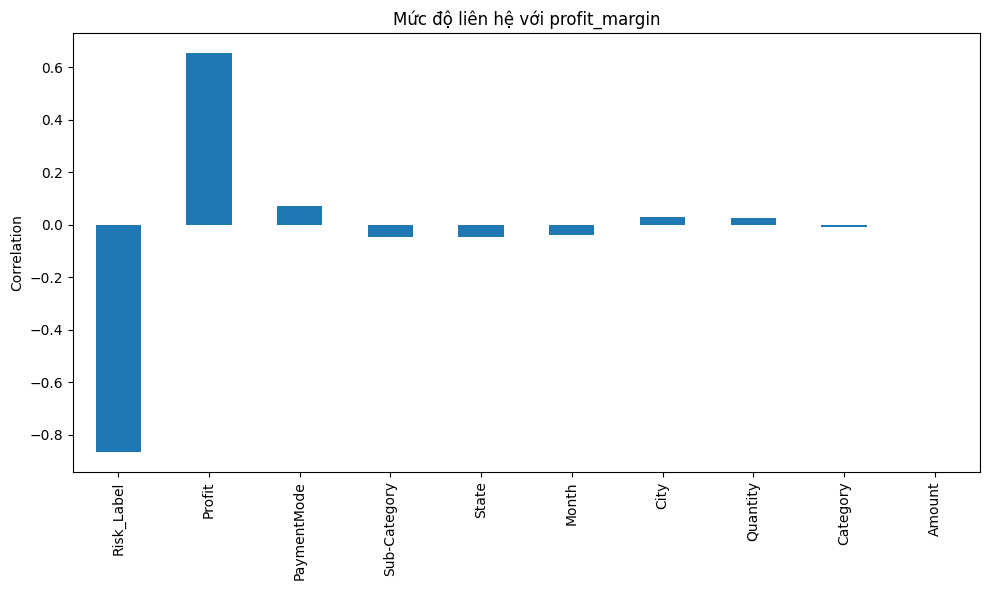

In [123]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()

# Encode biến phân loại
for col in df_encoded.select_dtypes(include='object').columns:
    df_encoded[col] = LabelEncoder().fit_transform(df_encoded[col].astype(str))

# Tính tương quan
corr = df_encoded.corr(numeric_only=True)['Profit_Margin']
corr = corr.drop('Profit_Margin').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10,6))
corr.plot(kind='bar')
plt.title('Mức độ liên hệ với profit_margin')
plt.ylabel('Correlation')
plt.tight_layout()
plt.show()

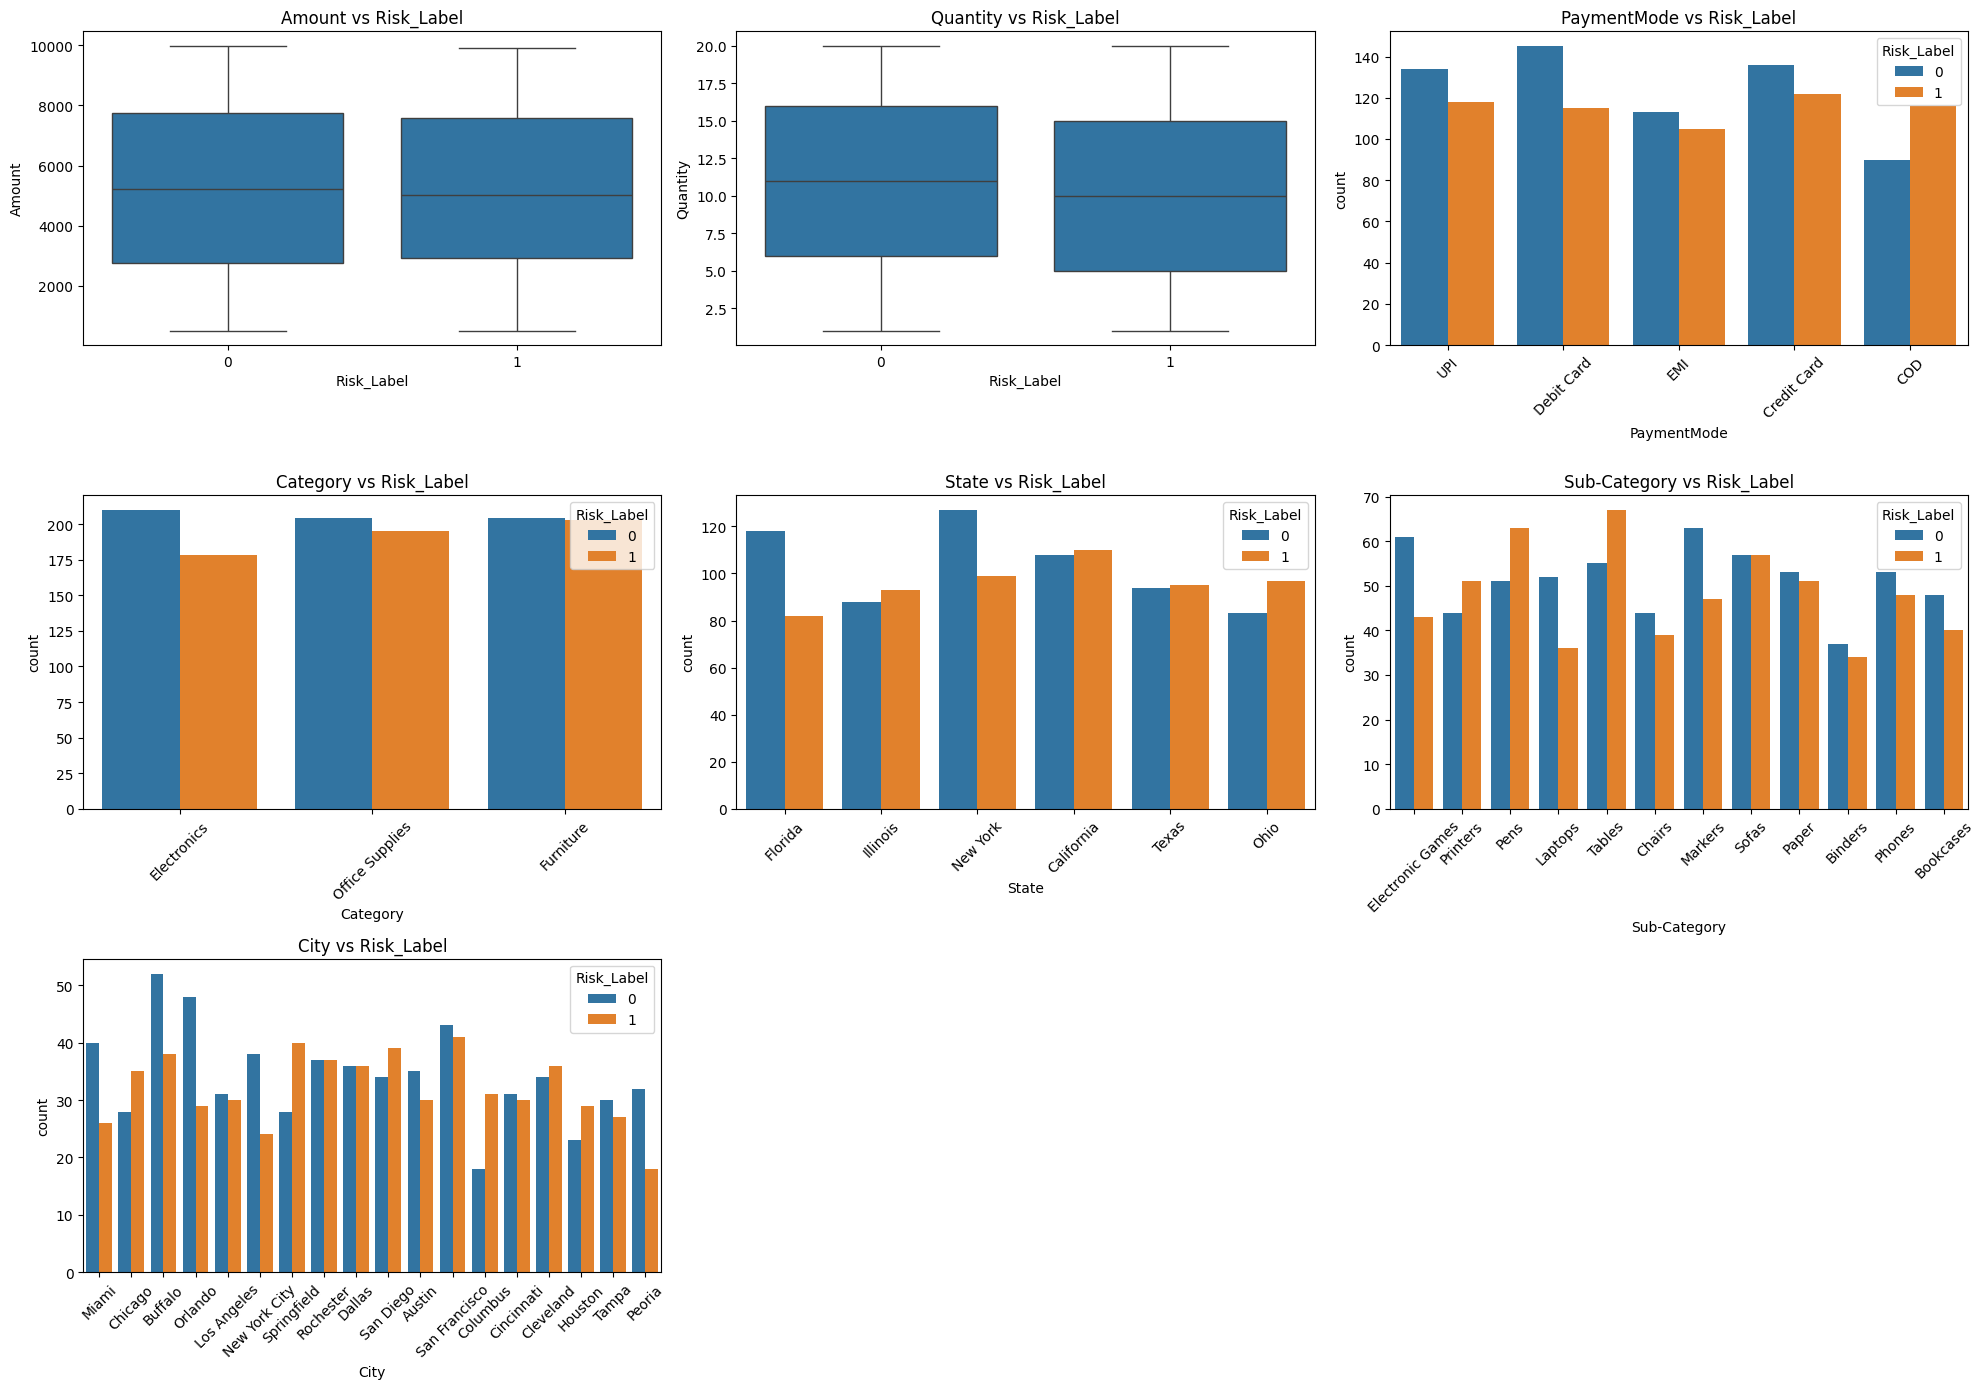

In [124]:

target = "Risk_Label"

numeric_cols = ["Amount", "Quantity"]

categorical_cols = [
    "PaymentMode",
    "Category",
    "State",
    "Sub-Category",
    "City"
]

# ==========================
# FIGURE GRID 3x3 = 9 plots
# ==========================
fig, axes = plt.subplots(3, 3, figsize=(20, 14))
axes = axes.flatten()

plot_index = 0

# ==========================
# 1. Numeric → Boxplot (2 plots)
# ==========================
for col in numeric_cols:
    sns.boxplot(data=df, x=target, y=col, ax=axes[plot_index])
    axes[plot_index].set_title(f"{col} vs {target}")
    plot_index += 1

# ==========================
# 2. Categorical → Countplot (5 plots)
# ==========================
for col in categorical_cols:
    temp_df = df

    # nếu City hoặc category nhiều → lấy Top 10
    if df[col].nunique() > 20:
        top_vals = df[col].value_counts().nlargest(10).index
        temp_df = df[df[col].isin(top_vals)]

    sns.countplot(data=temp_df, x=col, hue=target, ax=axes[plot_index])
    axes[plot_index].set_title(f"{col} vs {target}")
    axes[plot_index].tick_params(axis='x', rotation=45)

    plot_index += 1

# ==========================
# Ẩn ô dư
# ==========================
for i in range(plot_index, len(axes)):
    axes[i].axis('off')

plt.tight_layout()
plt.show()

<Axes: xlabel='Risk_Label', ylabel='Amount'>

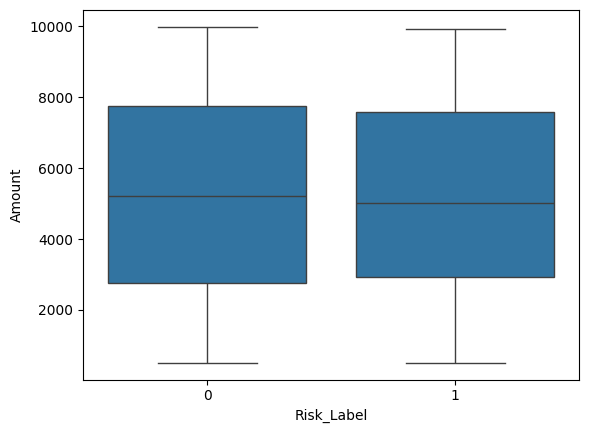

In [125]:
sns.boxplot(
    x=df["Risk_Label"],
    y=df["Amount"]
)

<Axes: xlabel='Risk_Label', ylabel='Quantity'>

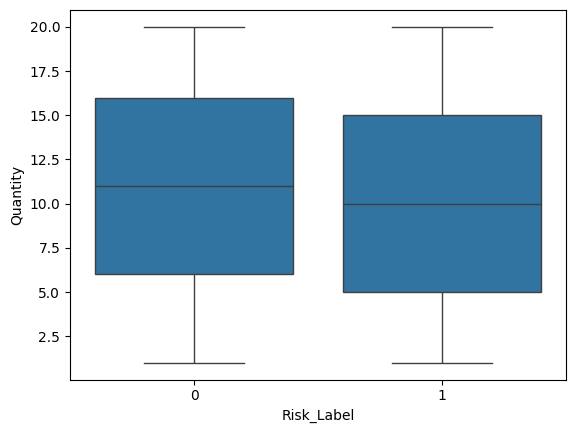

In [126]:
sns.boxplot(
    x=df["Risk_Label"],
    y=df["Quantity"]
)

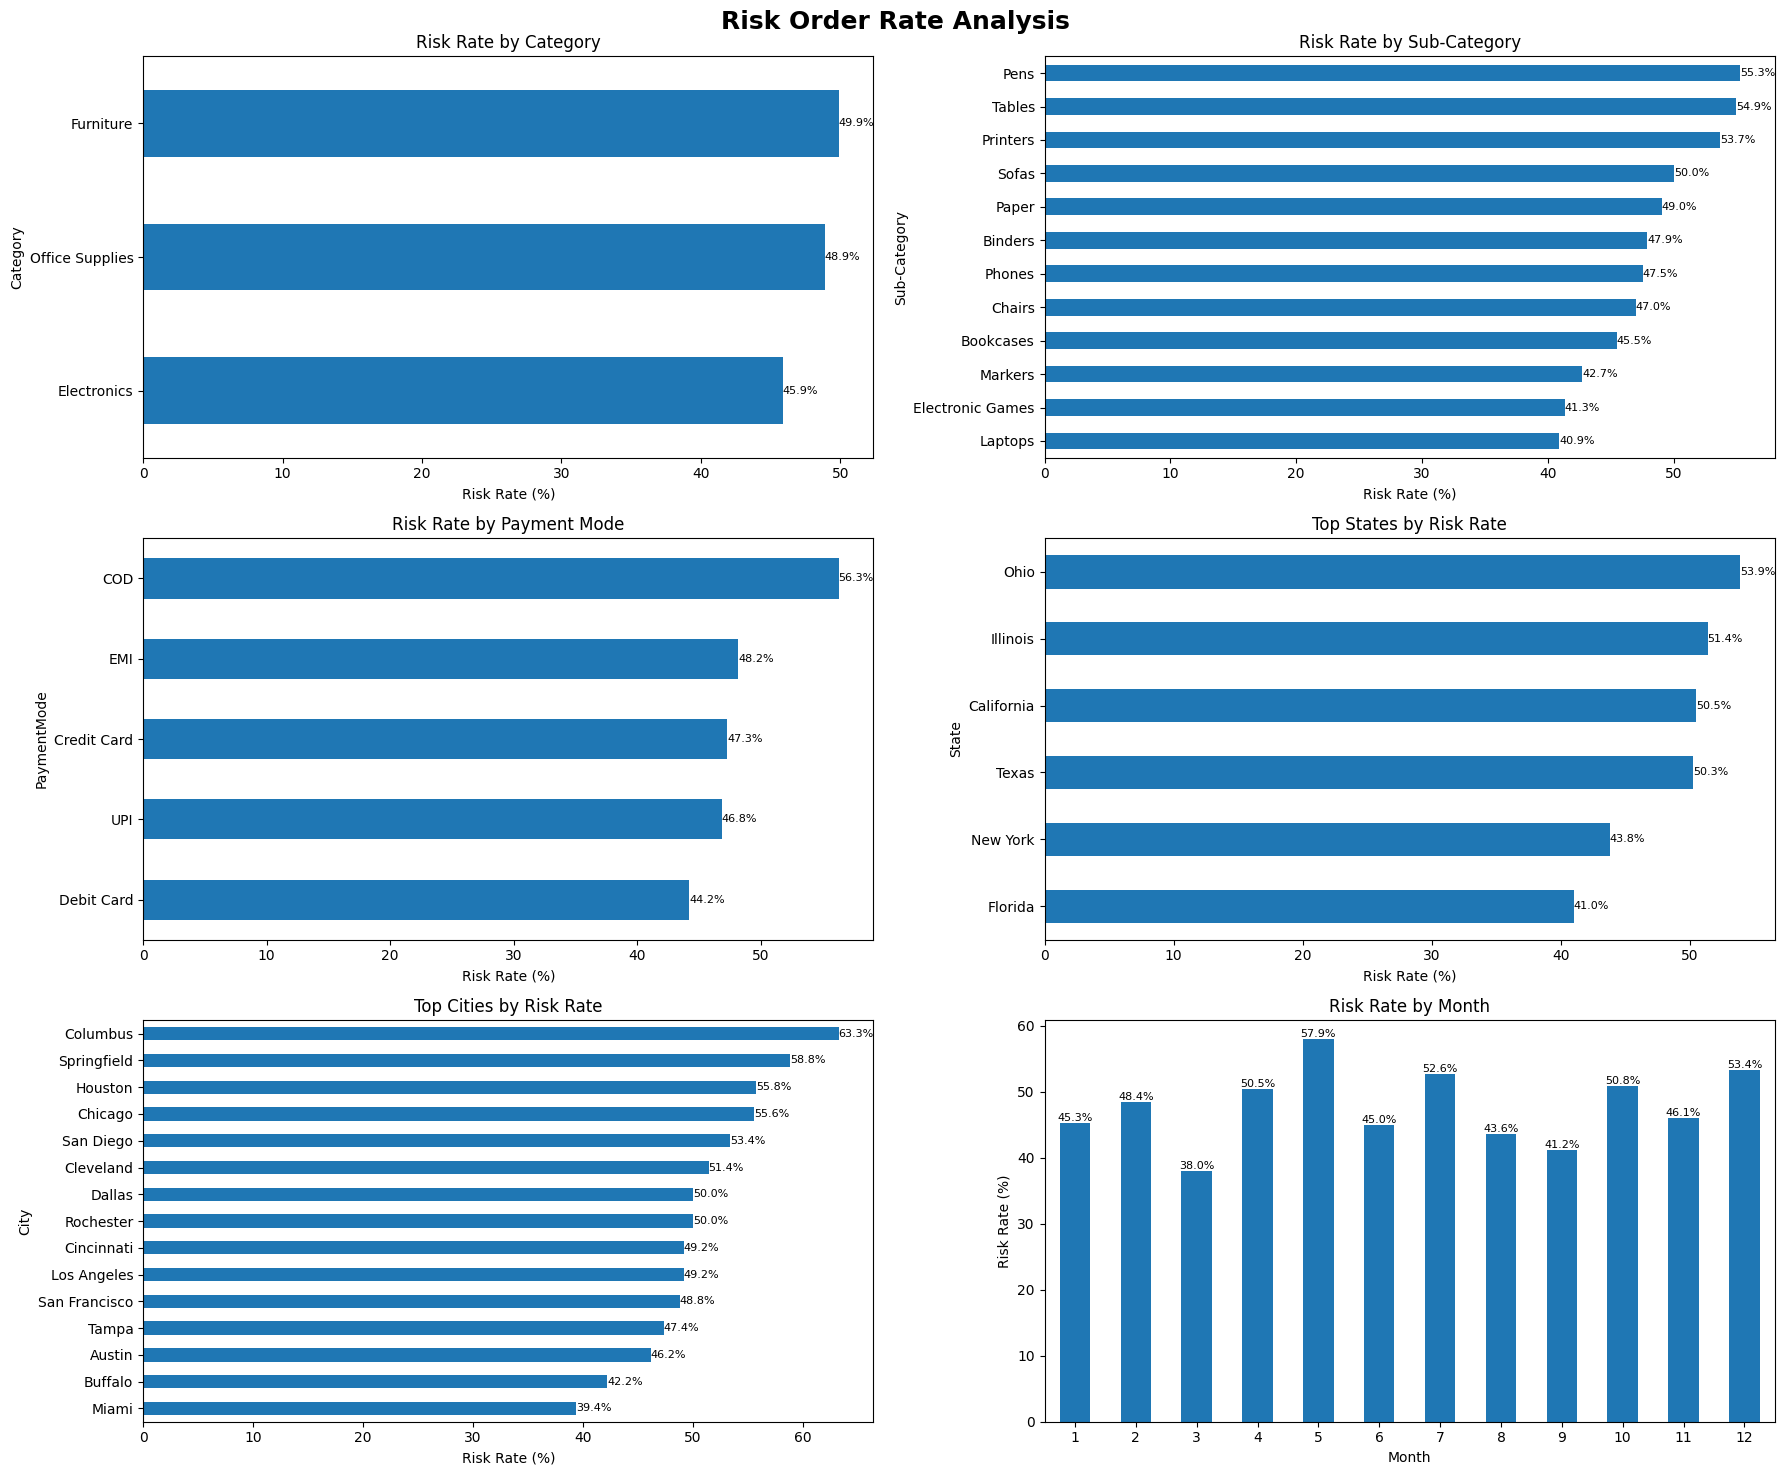

In [127]:
 #Hàm tính tỷ lệ đơn rủi ro
# ==========================
def risk_rate(df, group_col):
    return (
        df.groupby(group_col)["Risk_Label"]
        .apply(lambda x: (x == 1).mean() * 100)
        .sort_values()
    )

# ==========================
# Tạo figure 3x2
# ==========================
fig, axes = plt.subplots(3, 2, figsize=(18, 15))

# --------------------------
# 1. Category
# --------------------------
risk_rate(df, "Category").plot(
    kind="barh",
    ax=axes[0, 0]
)
axes[0, 0].set_title("Risk Rate by Category")
axes[0, 0].set_xlabel("Risk Rate (%)")

# --------------------------
# 2. Sub-Category
# --------------------------
risk_rate(df, "Sub-Category").plot(
    kind="barh",
    ax=axes[0, 1]
)
axes[0, 1].set_title("Risk Rate by Sub-Category")
axes[0, 1].set_xlabel("Risk Rate (%)")

# --------------------------
# 3. Payment Mode
# --------------------------
risk_rate(df, "PaymentMode").plot(
    kind="barh",
    ax=axes[1, 0]
)
axes[1, 0].set_title("Risk Rate by Payment Mode")
axes[1, 0].set_xlabel("Risk Rate (%)")

# --------------------------
# 4. State
# --------------------------
state_risk = risk_rate(df, "State")

state_risk.tail(15).plot(
    kind="barh",
    ax=axes[1, 1]
)
axes[1, 1].set_title("Top States by Risk Rate")
axes[1, 1].set_xlabel("Risk Rate (%)")

# --------------------------
# 5. City
# --------------------------
city_risk = risk_rate(df, "City")

city_risk.tail(15).plot(
    kind="barh",
    ax=axes[2, 0]
)
axes[2, 0].set_title("Top Cities by Risk Rate")
axes[2, 0].set_xlabel("Risk Rate (%)")

# --------------------------
# 6. Month
# --------------------------
month_risk = (
    df.groupby("Month")["Risk_Label"]
      .apply(lambda x: (x == 1).mean() * 100)
)

month_risk.plot(
    kind="bar",
    ax=axes[2, 1]
)

axes[2, 1].set_title("Risk Rate by Month")
axes[2, 1].set_xlabel("Month")
axes[2, 1].set_ylabel("Risk Rate (%)")
axes[2, 1].tick_params(axis='x', rotation=0)
# ==========================
# Hiển thị giá trị %
# ==========================
for ax in axes.flat:
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt='%.1f%%',
            fontsize=8
        )

# ==========================
# Tiêu đề chung
# ==========================
plt.suptitle(
    "Risk Order Rate Analysis",
    fontsize=18,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

In [128]:
from sklearn.preprocessing import LabelEncoder

df_processed = df.copy()

state_encoder = LabelEncoder()
city_encoder = LabelEncoder()

df_processed["State"] = state_encoder.fit_transform(df_processed["State"])
df_processed["City"] = city_encoder.fit_transform(df_processed["City"])

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
categorical_onehot = [
    "Sub-Category",
    "PaymentMode",
    "Category"
]

categorical_label = [
    "State",
    "City"
]
numeric_features = [
    "Amount",
    "Quantity",
    "State",
    "City"
]

preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_onehot)
    ]
)

In [129]:
features = [
    "Sub-Category",
    "PaymentMode",
    "Amount",
    "State",
    "Category",
    "Quantity",
    "City"
]

target = "Risk_Label"

X = df_processed[features]
y = df_processed[target]

In [130]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Original set --->", X.shape, y.shape)
print("Training set --->", X_train.shape, y_train.shape)
print("Testing set ---->", X_test.shape, y_test.shape)

Original set ---> (1194, 7) (1194,)
Training set ---> (955, 7) (955,)
Testing set ----> (239, 7) (239,)


In [131]:
counts = y_train.value_counts()
percent = y_train.value_counts(normalize=True) * 100

result = pd.DataFrame({
    'Count': counts,
    'Percentage (%)': percent
})

print(result)


            Count  Percentage (%)
Risk_Label                       
0             494       51.727749
1             461       48.272251


In [132]:
X_train = preprocess.fit_transform(X_train)
X_test = preprocess.transform(X_test)


feature_names = preprocess.get_feature_names_out()

X_train_df = pd.DataFrame(
    X_train.toarray(),
    columns=feature_names
)

X_train_df.info()
display(X_train_df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 955 entries, 0 to 954
Data columns (total 24 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   num__Amount                         955 non-null    float64
 1   num__Quantity                       955 non-null    float64
 2   num__State                          955 non-null    float64
 3   num__City                           955 non-null    float64
 4   cat__Sub-Category_Binders           955 non-null    float64
 5   cat__Sub-Category_Bookcases         955 non-null    float64
 6   cat__Sub-Category_Chairs            955 non-null    float64
 7   cat__Sub-Category_Electronic Games  955 non-null    float64
 8   cat__Sub-Category_Laptops           955 non-null    float64
 9   cat__Sub-Category_Markers           955 non-null    float64
 10  cat__Sub-Category_Paper             955 non-null    float64
 11  cat__Sub-Category_Pens              955 non-n

,num__Amount,num__Quantity,num__State,num__City,cat__Sub-Category_Binders,cat__Sub-Category_Bookcases,cat__Sub-Category_Chairs,cat__Sub-Category_Electronic Games,cat__Sub-Category_Laptops,cat__Sub-Category_Markers,cat__Sub-Category_Paper,cat__Sub-Category_Pens,cat__Sub-Category_Phones,cat__Sub-Category_Printers,cat__Sub-Category_Sofas,cat__Sub-Category_Tables,cat__PaymentMode_COD,cat__PaymentMode_Credit Card,cat__PaymentMode_Debit Card,cat__PaymentMode_EMI,cat__PaymentMode_UPI,cat__Category_Electronics,cat__Category_Furniture,cat__Category_Office Supplies
0,-1.603266,0.938158,0.340886,0.270745,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
1,0.824436,1.283347,-0.241487,1.399014,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,-0.415181,0.765563,-1.406232,1.210969,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
3,-1.645494,-1.132982,0.340886,-1.421658,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
4,-0.899362,-1.478172,-0.823860,1.587058,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
950,-1.314118,0.247778,-0.823860,0.458790,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
951,0.985830,-0.442602,-0.241487,0.646835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
952,1.340466,1.110753,1.505632,-0.481434,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
953,-1.520244,-0.270007,0.923259,-0.857523,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
